# Conditional Random Fields (CRFs) for POS tagging in NLP


Conditional Random Fields (CRFs) are widely used in NLP for Part-of-Speech (POS) tagging where each word in a sentence is assigned a grammatical label such as noun, verb or adjective.

As probabilistic sequence-labeling models, CRFs capture contextual and dependency relationships between neighboring words and tags, allowing more accurate labeling of entire sentences rather than individual words.

# How CRFs Work

CRFs model the entire sequence as a single structured prediction problem and assign scores to possible tag sequences.

They select the most probable global label sequence by combining feature weights and transition dependencies across the sentence.
CRF Probability:

P(Y∣X)=1/Z(X) exp⁡(∑i∑kλkfk(yi−1,yi,xi))


where

X: input words

Y: output tags

fk(): feature functions

λk : learned weights

Z(X): normalization factor

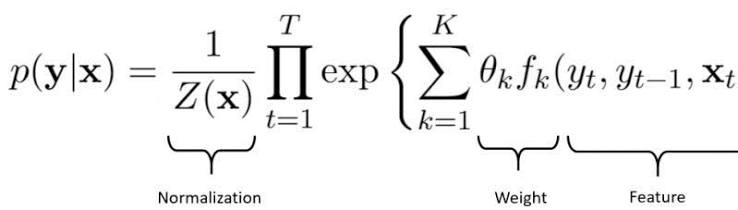

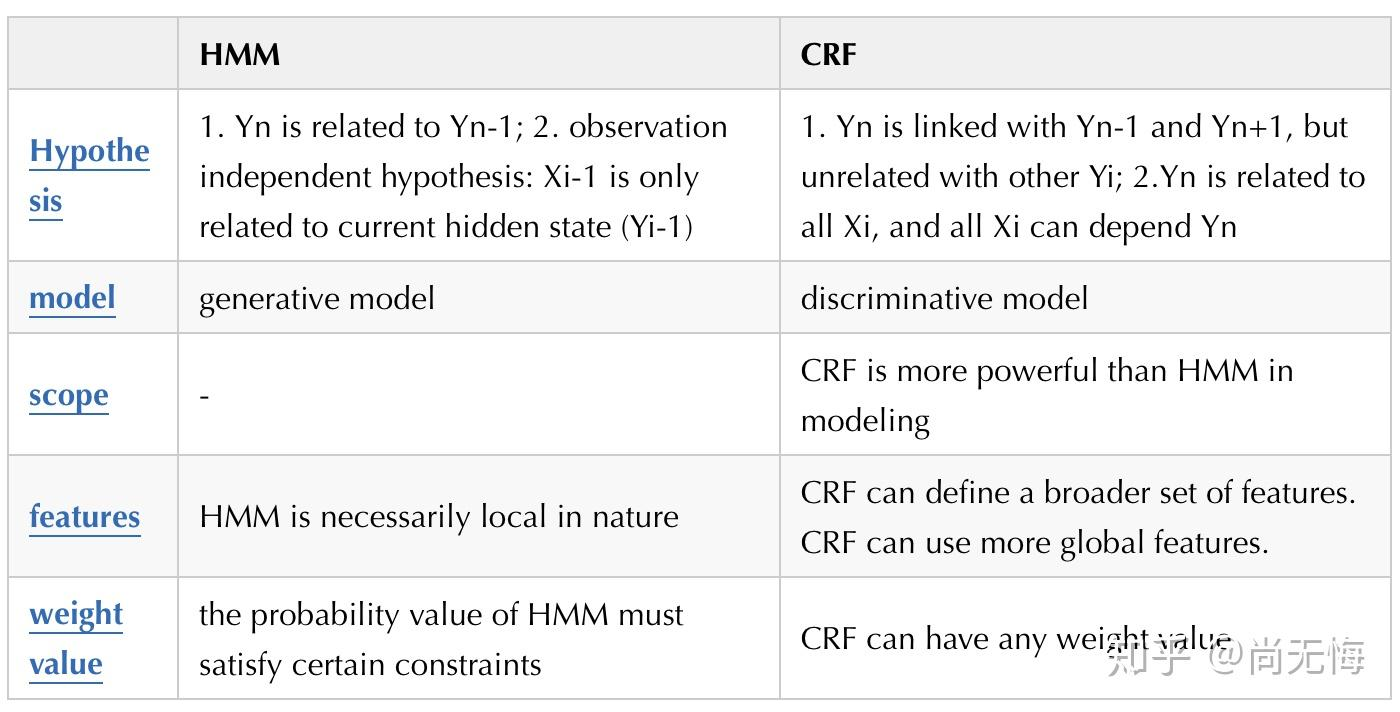

In [1]:
!pip install sklearn-crfsuite


In [2]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics

train_sents = [
    [('player', 'NN'), ('kicks', 'VB'), ('ball', 'NN')],
    [('runner', 'NN'), ('kicks', 'VB'), ('ball', 'NN')],
    [('runner', 'NN'), ('runs', 'VB'), ('fast', 'RB')],
]

def word2features(sent, i):
    word = sent[i][0]
    features = {
        "bias": 1.0,
        "word.lower()": word.lower(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
        "position": i,
        "is_first": i == 0,
        "is_last": i == len(sent) - 1,
    }
    if i > 0:
        prev_word = sent[i - 1][0]
        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:word[-3:]": prev_word[-3:],
        })
    else:
        features["BOS"] = True

    if i < len(sent) - 1:
        next_word = sent[i + 1][0]
        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:word[-3:]": next_word[-3:],
        })
    else:
        features["EOS"] = True

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [tag for _, tag in sent]

def sent2tokens(sent):
    return [word for word, _ in sent]

X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s) for s in train_sents]

crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True,
)
crf.fit(X_train, y_train)

def crf_tag_sentence(words):
    dummy_sent = [(w, "") for w in words]
    features = sent2features(dummy_sent)
    predicted = crf.predict_single(features)
    return list(zip(words, predicted))

if __name__ == "__main__":
    test_sentences = [
        ["player", "kicks", "ball"],
        ["runner", "runs", "fast"],
    ]

    for sent in test_sentences:
        tagged = crf_tag_sentence(sent)
        formatted = " ".join(f"{w}/{t}" for w, t in tagged)
        print(f"Input : {' '.join(sent)}")
        print(f"Output: {formatted}")
        print()

    print("Marginal tag probabilities for 'player kicks ball':")
    feats = sent2features([(w, "") for w in test_sentences[0]])
    marginals = crf.predict_marginals_single(feats)
    for word, probs in zip(test_sentences[0], marginals):
        prob_str = ", ".join(f"{tag}={p:.3f}" for tag, p in probs.items())
        print(f"  {word:8s}: {prob_str}")


Input : player kicks ball
Output: player/NN kicks/VB ball/NN

Input : runner runs fast
Output: runner/NN runs/VB fast/RB

Marginal tag probabilities for 'player kicks ball':
  player  : NN=0.924, VB=0.040, RB=0.037
  kicks   : NN=0.053, VB=0.901, RB=0.046
  ball    : NN=0.900, VB=0.044, RB=0.057


# Viterbi Algorithm for Hidden Markov Models (HMMs)

The Viterbi algorithm is a dynamic programming algorithm for finding the most likely sequence of hidden states in a Hidden Markov Model (HMM).

It is widely used in various applications such as speech recognition, bioinformatics, and natural language processing.

A Hidden Markov Model (HMM) is a statistical model that represents systems with hidden states and observable events. It consists of:

States: Hidden conditions that are not directly observable.


Observations: Observable events influenced by the hidden states.

Transition Probabilities: Probabilities of moving from one state to another.

Emission Probabilities: Probabilities of observing a particular event given a state.

Initial State Probabilities: Probabilities of the system starting in a particular state.

# The Viterbi Algorithm
The Viterbi algorithm is a fundamental dynamic programming technique widely used in the context of Hidden Markov Models (HMMs) to uncover the most likely sequence of hidden states given a sequence of observed events.

Given a series of observed events, the Viterbi algorithm determines the most likely order of hidden states in an HMM.

Andrew Viterbi, who first proposed the algorithm in 1967, is honored by the algorithm's name.

The most likely sequence of states is computed efficiently by the Viterbi method, which divides the issue into smaller subproblems and solves them recursively.

The Viterbi algorithm operates by iteratively computing the highest probability paths to each state at each time step, storing these probabilities, and backtracking to determine the most probable sequence of hidden states.

This method ensures an efficient and accurate decoding of hidden state sequences, making it indispensable for applications that require precise sequence analysis and pattern recognition.

**Optimizing Viterbi Algorithm**
To optimize the Viterbi algorithm, consider the following:

**Pruning**: Reducing the state space by eliminating states with very low probabilities.

**Logarithms**: Using log probabilities to avoid underflow issues.

**Beam Search**: Keeping track of only the top kkk most likely paths at each step to reduce computational complexity.



In [3]:
import numpy as np

def viterbi(obs, states, start_p, trans_p, emit_p):
    V = [{}]
    path = {}

    for y in states:
        V[0][y] = start_p[y] * emit_p[y][obs[0]]
        path[y] = [y]

    for t in range(1, len(obs)):
        V.append({})
        newpath = {}

        for y in states:
            (prob, state) = max(
                [(V[t-1][y0] * trans_p[y0][y] * emit_p[y][obs[t]], y0) for y0 in states]
            )
            V[t][y] = prob
            newpath[y] = path[state] + [y]

        path = newpath

    (prob, state) = max([(V[-1][y], y) for y in states])
    return (prob, path[state])

states = ('Rainy', 'Sunny')
observations = ('Walk', 'Shop', 'Clean')
start_probability = {'Rainy': 0.6, 'Sunny': 0.4}
transition_probability = {
   'Rainy' : {'Rainy': 0.7, 'Sunny': 0.3},
   'Sunny' : {'Rainy': 0.4, 'Sunny': 0.6},
   }
emission_probability = {
   'Rainy' : {'Walk': 0.1, 'Shop': 0.4, 'Clean': 0.5},
   'Sunny' : {'Walk': 0.6, 'Shop': 0.3, 'Clean': 0.1},
   }

print(viterbi(observations, states, start_probability, transition_probability, emission_probability))


(0.01344, ['Sunny', 'Rainy', 'Rainy'])


In [4]:
!pip install hmmlearn

In [5]:
import numpy as np
from hmmlearn import hmm

states = ["NN", "VB", "RB"]
state2idx = {s: i for i, s in enumerate(states)}

vocab = ["player", "runner", "ball", "kicks", "runs", "fast"]
word2idx = {w: i for i, w in enumerate(vocab)}

n_states = len(states)
n_words = len(vocab)

model = hmm.CategoricalHMM(n_components=n_states, n_iter=100, random_state=0)

model.startprob_ = np.array([1.0, 0.0, 0.0])

model.transmat_ = np.array([
    [0.00, 1.00, 0.00],
    [0.667, 0.00, 0.333],
    [1/3,  1/3,  1/3],
])

model.emissionprob_ = np.array([
    [0.4,  0.4,  0.2,  0.0,   0.0,  0.0],
    [0.0,  0.0,  0.0,  0.667, 0.333, 0.0],
    [0.0,  0.0,  0.0,  0.0,   0.0,  1.0],
])

def hmm_tag_sentence(words):
    obs_seq = np.array([[word2idx[w]] for w in words])
    log_prob, state_seq = model.decode(obs_seq, algorithm="viterbi")
    tags = [states[i] for i in state_seq]
    return list(zip(words, tags)), np.exp(log_prob)

if __name__ == "__main__":
    test_sentences = [
        ["player", "kicks", "ball"],
        ["runner", "runs", "fast"],
    ]

    for sent in test_sentences:
        tagged, prob = hmm_tag_sentence(sent)
        formatted = " ".join(f"{w}/{t}" for w, t in tagged)
        print(f"Input : {' '.join(sent)}")
        print(f"Output: {formatted}")
        print(f"Path probability: {prob:.6f}")
        print()

    print("Posterior state probabilities for 'player kicks ball':")
    obs = np.array([[word2idx[w]] for w in test_sentences[0]])
    posteriors = model.predict_proba(obs)
    for word, probs in zip(test_sentences[0], posteriors):
        prob_str = ", ".join(f"{s}={p:.3f}" for s, p in zip(states, probs))
        print(f"  {word:8s}: {prob_str}")


Input : player kicks ball
Output: player/NN kicks/VB ball/NN
Path probability: 0.035591

Input : runner runs fast
Output: runner/NN runs/VB fast/RB
Path probability: 0.044356

Posterior state probabilities for 'player kicks ball':
  player  : NN=1.000, VB=0.000, RB=0.000
  kicks   : NN=0.000, VB=1.000, RB=0.000
  ball    : NN=1.000, VB=0.000, RB=0.000


--- CRF Model Performance ---
              precision    recall  f1-score   support

          NN       1.00      1.00      1.00         3
          RB       1.00      1.00      1.00         1
          VB       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


--- HMM Model Performance ---
              precision    recall  f1-score   support

          NN       1.00      1.00      1.00         3
          RB       1.00      1.00      1.00         1
          VB       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



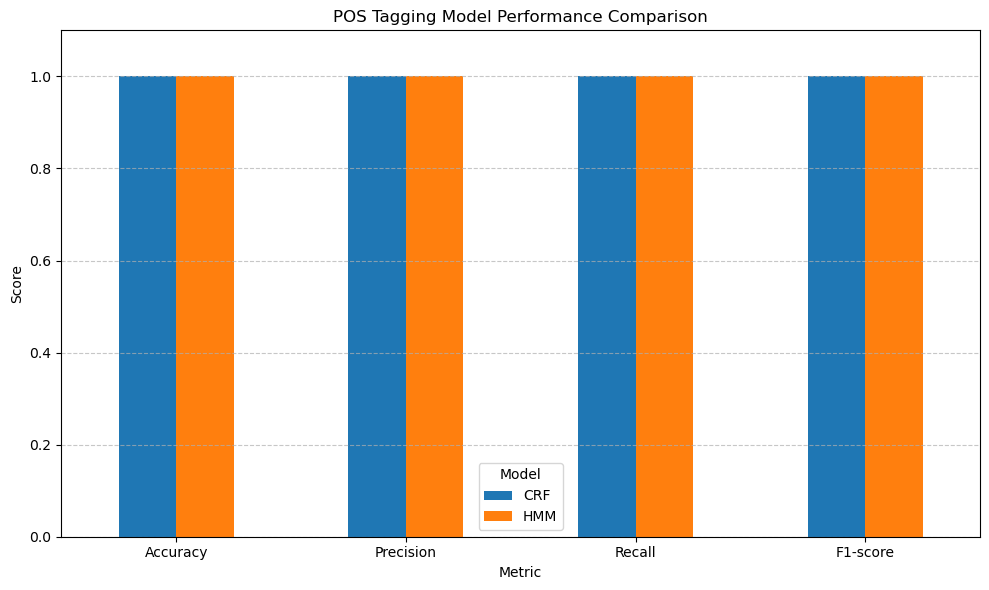

In [6]:
import numpy as np
from hmmlearn import hmm
from sklearn_crfsuite import metrics
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

gold_test_sents = [
    [('player', 'NN'), ('kicks', 'VB'), ('ball', 'NN')],
    [('runner', 'NN'), ('runs', 'VB'), ('fast', 'RB')],
]

test_words_for_pred = [[word for word, tag in sent] for sent in gold_test_sents]

def sent2labels(sent):
    return [tag for _, tag in sent]

y_true_sents = [sent2labels(s) for s in gold_test_sents]
y_true_flat = [tag for sublist in y_true_sents for tag in sublist]

all_possible_tags = sorted(list(set([tag for sentence in train_sents for word, tag in sentence])))
all_possible_tags = sorted(list(set(all_possible_tags + list(set(y_true_flat)))))

crf_predictions_sents = [crf_tag_sentence(words) for words in test_words_for_pred]
y_pred_crf_flat = [tag for sublist in crf_predictions_sents for _, tag in sublist]

hmm_predictions_sents = [hmm_tag_sentence(words)[0] for words in test_words_for_pred]
y_pred_hmm_flat = [tag for sublist in hmm_predictions_sents for _, tag in sublist]

print('--- CRF Model Performance ---')
crf_report_dict = classification_report(y_true_flat, y_pred_crf_flat, labels=all_possible_tags, output_dict=True, zero_division=0)
print(classification_report(y_true_flat, y_pred_crf_flat, labels=all_possible_tags, zero_division=0))

print('\n--- HMM Model Performance ---')
hmm_report_dict = classification_report(y_true_flat, y_pred_hmm_flat, labels=all_possible_tags, output_dict=True, zero_division=0)
print(classification_report(y_true_flat, y_pred_hmm_flat, labels=all_possible_tags, zero_division=0))

data_for_plot = []
data_for_plot.append({'Metric': 'Accuracy', 'CRF': crf_report_dict['accuracy'], 'HMM': hmm_report_dict['accuracy']})
data_for_plot.append({'Metric': 'Precision', 'CRF': crf_report_dict['weighted avg']['precision'], 'HMM': hmm_report_dict['weighted avg']['precision']})
data_for_plot.append({'Metric': 'Recall', 'CRF': crf_report_dict['weighted avg']['recall'], 'HMM': hmm_report_dict['weighted avg']['recall']})
data_for_plot.append({'Metric': 'F1-score', 'CRF': crf_report_dict['weighted avg']['f1-score'], 'HMM': hmm_report_dict['weighted avg']['f1-score']})

plot_df = pd.DataFrame(data_for_plot).set_index('Metric')

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='bar', ax=ax, rot=0)
ax.set_title('POS Tagging Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
